
Mirna N. Kapetina,

Decembar 2023

## Problem: Problem trgovačkog putnika (TSP)
TSP podrazumeva pronalaženje najkraćeg mogućeg puta kojim bi se obišao određeni skup gradova, prolazeći kroz svaki grad jednom i vraćajući se u početni grad. Cilj je minimizovati ukupnu pređenu udaljenost.


Implementacija GA algoritma za ovaj problem je specifična po tome što je jedinka, odnosno potencijalno rešenje skup brojeva (ili slova)  gradova, npr
$Ј=[E\; D\; A\; B\; C]$ ili $Ј=[5\; 4\; 1\; 2\; 3]$  što bi značilo da ova jedinka predlaže rešenje da se gradovi obiđu u sledećem redosledu:
$E→ D→  A→  B→  C$ . Druga neka jedinka bi bila drugo potencijalno rešenje pa je i ona permutacija tačno ovog skupa slova $Ј=[A\; D\; E\; B\; C]$.

Da budemo precizniji, ovo je Genetski algoritam kod kog se jedinka kodira kao permutacija određenog skupa brojeva. Ovako kodirani GA algoritam ima specifičnost po pitanju realizacije određenih funkcija, kao što su npr ukrštanje i mutacija, jer nove dobijene jedinke opet moraju imati elemente iz istog skupa brojeva. Ove funkcije se mogu realizovati na različite načine, a u nastavku dajemo neka moguća rešenja.



Pristup genetskog algoritma:
U ovom primeru, rešenje (mogući put) predstavićemo permutacijom gradova. Genetski algoritam će evoluirati populaciju ruta kroz generacije, koristeći operacije ukrštanja (crossover) i mutacije.

In [1]:
import random
from itertools import permutations

# Inicijalizacija populacije je u ovom slučaju skup permutacija skupa gradova
cities = {
    'A': (0, 0),
    'B': (1, 2),
    'C': (3, 1),
    'D': (5, 2),
    'E': (6, 0)
}
def generate_initial_population(size):
    cities_list = list(cities.keys())
    all_permutations = list(permutations(cities_list))
    return [list(perm) for perm in random.sample(all_permutations, size)]



In [2]:
#Primer
generate_initial_population(5)

[['C', 'E', 'D', 'A', 'B'],
 ['B', 'E', 'A', 'C', 'D'],
 ['D', 'A', 'C', 'E', 'B'],
 ['A', 'C', 'B', 'E', 'D'],
 ['C', 'B', 'A', 'E', 'D']]

## Fitnes funkcija
U ovom primeru fitnes funkcija je ukupna dužina putanje, pa se računa suma Euklidskih rastojanja između gradova

In [2]:
# Function to calculate the total distance of a route
def calculate_distance(route):
    total_distance = 0
    for i in range(len(route) - 1):
        city1 = route[i]
        city2 = route[i + 1]
        total_distance += ((cities[city2][0] - cities[city1][0]) ** 2 +
                           (cities[city2][1] - cities[city1][1]) ** 2) ** 0.5
    return total_distance

In [3]:
#Primer
J=['C', 'D', 'B', 'E', 'A']
calculate_distance(J)

17.621232784634294

# Ukrštanje

Ukrštanje može da se realizuje na više načina, a ovo je primer.
Imamo dve jedinke

J1 = ['C', 'D', 'B', 'E', 'A'],

<font color='red'>J2 = ['C', 'A', 'D', 'E', 'B']</font>

Nasumično odaberemo tačku ukrštanja, npr 3, i u prvu jedinku idu svi gradovi to tačke ukrštanja, a ostatak su gradovi iz jedinke J2 al koji se nisu već našli u J1,
![picture](https://drive.google.com/uc?id=156iKG64bvmdB59tFC16auE1WgnhPW0xP)



In [4]:
# Perform crossover to create a new generation
def crossover(pairs):
  children = []

  for parent1,parent2 in pairs:
    crossover_point = random.randint(1, len(parent1) - 1)
    #crossover_point=3
    child1 = parent1[:crossover_point] + [city for city in parent2 if city not in parent1[:crossover_point]]
    child2 = parent2[:crossover_point] + [city for city in parent1 if city not in parent2[:crossover_point]]
    children.append(child1)
    children.append(child2)
  return children

In [5]:
#Primer
J1=['C', 'D', 'B', 'E', 'A']
J2=['C', 'A', 'D', 'E', 'B']
crossover([[J1, J2]])


[['C', 'D', 'B', 'A', 'E'], ['C', 'A', 'D', 'B', 'E']]

## Mutacija
Kao i ukrštanje, mutacija se može realizovati na više načina. Jedan od njih je da izaberemo dve tačke i rotiramo ih. Kao na slici u prilogu
![picture](https://drive.google.com/uc?id=1kKUUAE3PjmCLuA07v_SUtksczdq2Oc-b)





In [7]:
# Perform mutation on an individual route
def mutate(chromosomes,mutation_rate):
  mutated_chromosomes = []
  for route in chromosomes:

    if random.random() < mutation_rate:
        mutation_point1 = random.randint(0, len(route) - 1)
        mutation_point2 = random.randint(0, len(route) - 1)
    #    mutation_point1 = 2
    #    mutation_point2 = 4
        route[mutation_point1], route[mutation_point2] = route[mutation_point2], route[mutation_point1]

    mutated_chromosomes.append(route)
  return mutated_chromosomes

In [8]:
#Primer
J1=['C', 'D', 'B', 'E', 'A']
mutation_rate=0.9
mutate([J1],mutation_rate)


[['E', 'D', 'B', 'C', 'A']]

# Kompletan GA algoritam

Na kraju smo skupili sve definisane operacije na jedno mesto i implementirali GA algoritam za rešavanje problema Trgovačkog putnika. Algoritam se sastoji kao i svaki drugi GA algortam od sledećih koraka:



1.   Inicijalizacija početne populacije
2.   Iteriranje kroz generacije (svaka iteracija GA)

    1.   Biranje parova roditelja (ovde je napravljena random selekcija, iako znate da to nije vrsta selekcije koja se preporučuje pa možete staviti neku drugu kao što je rulet selekcija)
    2.   Ukrštanje parova roditelja i generisanje potomaka, dece
    3. Mutacija potpomaka, dece jedinki

    4. Ponavljanje postupka do maksimalnog broja generacija

3. Crtanje najboljeg rešenja

NAPOMENA: Ovde nemamo elitizam. On može da se doda, kao i neki drugi kriterijum zaustavljanja.













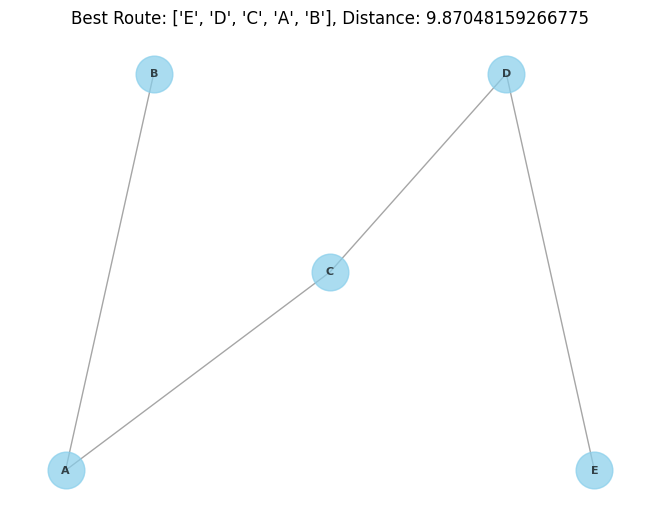

In [9]:

import random
import networkx as nx
import matplotlib.pyplot as plt
from itertools import permutations

# Define the problem: list of cities and their coordinates
cities = {
    'A': (0, 0),
    'B': (1, 2),
    'C': (3, 1),
    'D': (5, 2),
    'E': (6, 0)
}

# Genetic Algorithm Parameters
population_size = 50
generations = 100
mutation_rate = 0.02

# Function to calculate the total distance of a route
def calculate_distance(route):
    total_distance = 0
    for i in range(len(route) - 1):
        city1 = route[i]
        city2 = route[i + 1]
        total_distance += ((cities[city2][0] - cities[city1][0]) ** 2 +
                           (cities[city2][1] - cities[city1][1]) ** 2) ** 0.5
    return total_distance

# Initialize the population with random routes
def generate_initial_population(size):
    cities_list = list(cities.keys())
    all_permutations = list(permutations(cities_list))
    return [list(perm) for perm in random.sample(all_permutations, size)]


def rank_chromosomes(cost, chromosomes):
  costs = list(map(cost, chromosomes))
  ranked  = sorted( list(zip(chromosomes,costs)), key = lambda c:c[1])

  return list(zip(*ranked))

def random_selection(parents,fitness_scores):
  pairs = []
  for i in range(0, len(parents), 2):
    pair=random.choices(parents, weights=fitness_scores, k=2)
    pairs.append(pair)
  return pairs


# Perform crossover to create a new generation
def crossover(pairs):
  children = []

  for parent1,parent2 in pairs:
    crossover_point = random.randint(1, len(parent1) - 1)
    #crossover_point=3
    child1 = parent1[:crossover_point] + [city for city in parent2 if city not in parent1[:crossover_point]]
    child2 = parent2[:crossover_point] + [city for city in parent1 if city not in parent2[:crossover_point]]
    children.append(child1)
    children.append(child2)
  return children

# Perform mutation on an individual route
def mutate(chromosomes):
  mutated_chromosomes = []
  for route in chromosomes:

    if random.random() < mutation_rate:
        mutation_point1 = random.randint(0, len(route) - 1)
        mutation_point2 = random.randint(0, len(route) - 1)
        route[mutation_point1], route[mutation_point2] = route[mutation_point2], route[mutation_point1]

    mutated_chromosomes.append(route)
  return mutated_chromosomes

# Genetic Algorithm
def genetic_algorithm():
    population = generate_initial_population(population_size)

    for generation in range(generations):
        ranked_parents, costs = rank_chromosomes(calculate_distance, population)
        # Evaluate fitness of each route
        fitness_scores = [1 / calculate_distance(route) for route in population]

        # Select parents based on fitness
        # VODITE RACUNA DA JE OVDE ODABRANA RANDOM SELEKCIJA A MOZDA JE BOLJE DA SE KORISTI NEKA OD PREDAVANIH
        #KAO STO JE NPR RULET SELEKCIJA
        pairs = random_selection(ranked_parents,fitness_scores)

      #  print(pairs)
        # Create the next generation using crossover
        children = crossover(pairs)
      #  print(children)
        # Apply mutation
        chromosomes = mutate(children)


        # Replace a random route in the population with the child
        ranked_children, costs = rank_chromosomes(calculate_distance, chromosomes)


        # Print the best route in each generation
        best_route = min(ranked_children, key=calculate_distance)
      #  print(f"Generation {generation + 1}: Best Route {best_route}, Distance {calculate_distance(best_route)}")

    # Print the final best route
    best_route = min(population, key=calculate_distance)
 #   print(f"Final Best Route: {best_route}, Distance: {calculate_distance(best_route)}")

    # Plot the TSP graph for the best route
    tsp_graph = nx.Graph()
    tsp_graph.add_nodes_from(best_route)
    tsp_graph.add_edges_from([(best_route[i], best_route[i + 1]) for i in range(len(best_route) - 1)])
    pos = {city: cities[city] for city in tsp_graph.nodes}
    nx.draw(tsp_graph, pos, with_labels=True, node_size=700, node_color='skyblue', font_size=8, font_color='black', font_weight='bold', edge_color='gray', linewidths=1, alpha=0.7)
    plt.title(f"Best Route: {best_route}, Distance: {calculate_distance(best_route)}")


# Run the genetic algorithm
genetic_algorithm()